# 01. Exploratory Data Analysis

## Goal
Understand the structure, quality, and demand patterns in the retail sales dataset before building forecasting models.

## What This Notebook Shows
- dataset shape, columns, and missing values
- total daily sales behavior over time
- monthly demand patterns and seasonality
- a sample store_1 / item_1 demand series for downstream modeling

## Why It Matters
This step confirms whether the data is usable for forecasting and highlights the time-based patterns that matter for supply chain planning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/retail_sales.csv")
df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())

Shape: (4565000, 8)

Columns:
['date', 'store_id', 'item_id', 'sales', 'price', 'promo', 'weekday', 'month']

Missing values:


date        0
store_id    0
item_id     0
sales       0
price       0
promo       0
weekday     0
month       0
dtype: int64


In [4]:
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df["day"] = df["date"].dt.day
df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)

print("Date range:", df["date"].min(), "to", df["date"].max())
print("Stores:", df["store_id"].nunique())
print("Items:", df["item_id"].nunique())

df.head()

Date range: 2019-01-01 00:00:00 to 2023-12-31 00:00:00
Stores: 50


Items: 50


,date,store_id,item_id,sales,price,promo,weekday,month,year,day,weekofyear
0,2019-01-01,store_1,item_1,41,21.30,0,1,1,2019,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1,2019,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1,2019,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1,2019,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1,2019,5,1


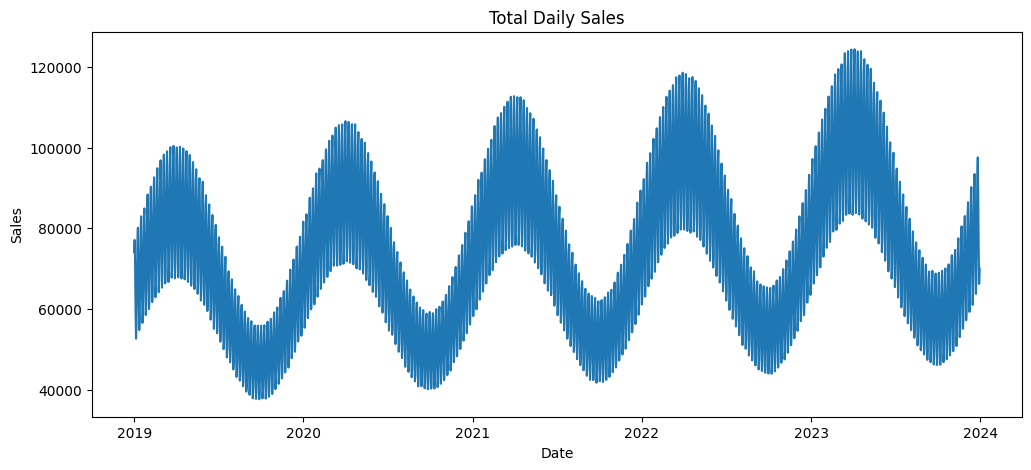

In [5]:
daily_sales = df.groupby("date")["sales"].sum()

plt.figure(figsize=(12, 5))
plt.plot(daily_sales.index, daily_sales.values)
plt.title("Total Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

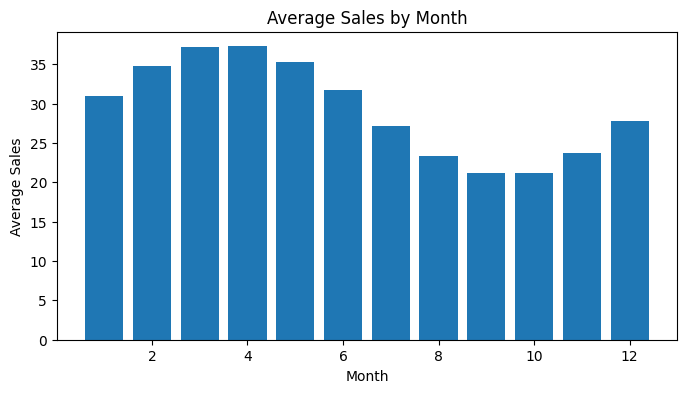

In [6]:
monthly_sales = df.groupby("month")["sales"].mean()

plt.figure(figsize=(8, 4))
plt.bar(monthly_sales.index, monthly_sales.values)
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()

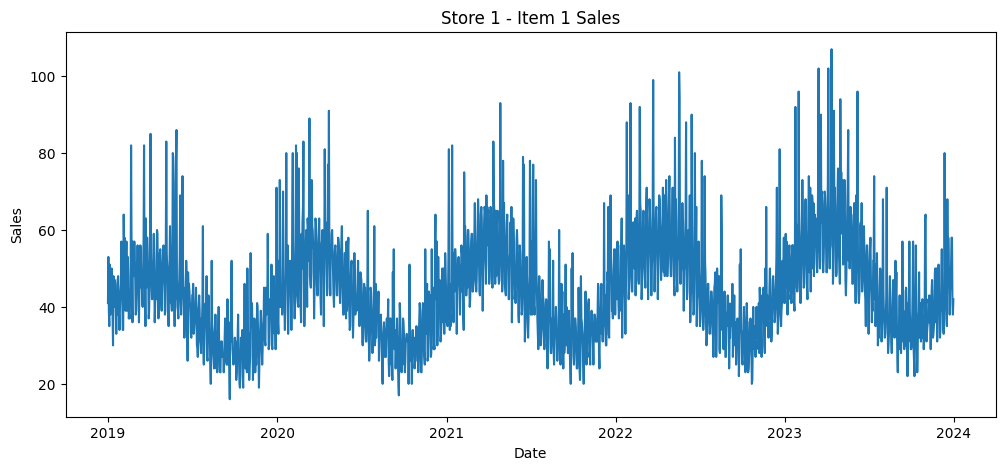

In [7]:
sample = df[(df["store_id"] == "store_1") & (df["item_id"] == "item_1")].copy()

plt.figure(figsize=(12, 5))
plt.plot(sample["date"], sample["sales"])
plt.title("Store 1 - Item 1 Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

## Interpretation
- Total sales show repeated patterns over time, suggesting seasonality.
- Sales levels vary by month, which means a fixed inventory policy may be inefficient.
- A store-item level view shows daily demand variability, which is important for safety stock planning.